- Import required libraries

In [45]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

- Import dataset

In [46]:
df = pd.read_csv('customer_behavior_acquisition.csv', parse_dates=['signup_date', 'event_timestamp'])
df = df.drop(columns=['key'])
df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp
119995,1552,181,Amazon Fire TV,Smart TV,Samsung,US,EMEA,2024-11-08,billing,2425,8.93,Success,2024-07-04 19:38:26.819164
119996,4394,152,PS5,Set Top Box,Google,VN,Americas,2025-05-26,billing,1858,13.07,Failed,2025-07-31 08:02:36.006365
119997,4410,172,iPad,Set Top Box,Apple,CA,Americas,2024-11-04,signup,2999,14.79,Failed,2025-02-28 21:36:52.395120
119998,1082,169,iPad,Set Top Box,Amazon,CA,APAC,2024-07-06,signup,3823,2.54,Failed,2025-02-11 21:39:01.224203
119999,1832,242,PS5,Smart TV,Apple,FR,Americas,2025-09-01,playback,2734,13.31,Failed,2026-03-18 23:53:18.511336


- Keep only retention event

In [47]:
df = df[(df['event_type'] == 'billing') & (df['payment_status']== 'Success')].copy()
df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp
119989,2722,410,Amazon Fire TV,Streaming Stick,Apple,FR,APAC,2025-03-21,billing,1839,4.51,Success,2024-09-06 20:16:20.062171
119991,3927,437,PS5,Game Console,Google,CA,EMEA,2025-06-21,billing,1199,5.80,Success,2024-06-23 19:49:18.419641
119993,2210,134,iPad,Smart TV,Google,ES,EMEA,2024-10-03,billing,1104,9.66,Success,2026-01-13 19:25:43.430291
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062
119995,1552,181,Amazon Fire TV,Smart TV,Samsung,US,EMEA,2024-11-08,billing,2425,8.93,Success,2024-07-04 19:38:26.819164


- Create a cohort group for each customer based on their first purchase date
- Transform the event_timestamp to extract the month period

In [48]:
df['first_event'] = (
    df.groupby('member_id')['event_timestamp']
    .transform('min')
)

df['cohort_first_month'] = (
    df['first_event']
    .dt.to_period('M')
)
df['event_month'] = df['event_timestamp'].dt.to_period('M')
df = df[(df['event_month'] <= pd.Period('2025-12', freq='M')) 
            & (df['event_month'] >= pd.Period('2025-01', freq='M'))
            & (df['cohort_first_month'] <= pd.Period('2025-12', freq='M')) 
            & (df['cohort_first_month'] >= pd.Period('2025-01', freq='M'))]
df.tail()

,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,first_event,cohort_first_month,event_month
119798,3352,459,Amazon Fire TV,Tablet,Samsung,ES,Americas,2026-04-01,billing,2834,2.53,Success,2025-02-12 05:12:08.664034,2025-02-12 05:12:08.664034,2025-02,2025-02
119827,3338,366,Chromecast,Streaming Stick,Amazon,CA,Americas,2025-07-09,billing,3955,17.56,Success,2025-03-18 01:28:50.435612,2025-03-18 01:28:50.435612,2025-03,2025-03
119875,2329,433,PS5,Streaming Stick,Google,ES,APAC,2025-03-01,billing,3259,15.51,Success,2025-12-15 14:04:45.391062,2025-02-27 11:40:13.990470,2025-02,2025-12
119901,1247,442,Chromecast,Smart TV,Google,DE,EMEA,2025-08-15,billing,2096,5.43,Success,2025-10-13 18:46:03.212665,2025-10-01 23:17:06.674462,2025-10,2025-10
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062,2025-12-27 09:16:50.361062,2025-12,2025-12


In [49]:
df.dtypes

member_id                      int64
device_id                      int64
device_name                   object
device_category               object
partner_name                  object
country                       object
region                        object
signup_date           datetime64[ns]
event_type                    object
watch_time                     int64
amount                       float64
payment_status                object
event_timestamp       datetime64[ns]
first_event           datetime64[ns]
cohort_first_month         period[M]
event_month                period[M]
dtype: object

- Create the number of retention months

In [50]:

df['month_diff'] = (
    df['event_month'] - df['cohort_first_month']
).apply(lambda x: x.n)


df.tail()


,member_id,device_id,device_name,device_category,partner_name,country,region,signup_date,event_type,watch_time,amount,payment_status,event_timestamp,first_event,cohort_first_month,event_month,month_diff
119798,3352,459,Amazon Fire TV,Tablet,Samsung,ES,Americas,2026-04-01,billing,2834,2.53,Success,2025-02-12 05:12:08.664034,2025-02-12 05:12:08.664034,2025-02,2025-02,0
119827,3338,366,Chromecast,Streaming Stick,Amazon,CA,Americas,2025-07-09,billing,3955,17.56,Success,2025-03-18 01:28:50.435612,2025-03-18 01:28:50.435612,2025-03,2025-03,0
119875,2329,433,PS5,Streaming Stick,Google,ES,APAC,2025-03-01,billing,3259,15.51,Success,2025-12-15 14:04:45.391062,2025-02-27 11:40:13.990470,2025-02,2025-12,10
119901,1247,442,Chromecast,Smart TV,Google,DE,EMEA,2025-08-15,billing,2096,5.43,Success,2025-10-13 18:46:03.212665,2025-10-01 23:17:06.674462,2025-10,2025-10,0
119994,2954,407,Chromecast,Set Top Box,Sony,FR,EMEA,2024-05-13,billing,1081,5.19,Success,2025-12-27 09:16:50.361062,2025-12-27 09:16:50.361062,2025-12,2025-12,0


In [51]:
cohort_size = df[df['month_diff'] == 0].groupby('cohort_first_month')['member_id'].nunique().rename('cohort_size')

- Similar pratice in Looker Studio (Data Studio)

In [52]:
cohort_data = (
    df.groupby(['cohort_first_month', 'month_diff'])['member_id']
    .nunique()
    .reset_index()
    .rename(columns={'member_id': 'retained_users'})
)

cohort_data = cohort_data.join(cohort_size, on='cohort_first_month')
cohort_data['retention_rate'] = (
    cohort_data['retained_users'] / cohort_data['cohort_size'] * 100
).round(1)

In [53]:
cohort_data

,cohort_first_month,month_diff,retained_users,cohort_size,retention_rate
0,2025-01,0,110,110,100.0
1,2025-01,1,15,110,13.6
2,2025-01,2,19,110,17.3
3,2025-01,3,15,110,13.6
4,2025-01,4,18,110,16.4
...,...,...,...,...,...
73,2025-10,1,1,13,7.7
74,2025-10,2,2,13,15.4
75,2025-11,0,12,12,100.0
76,2025-11,1,3,12,25.0


In [54]:
cohort_pivot_percent = cohort_data.pivot_table(
    index='cohort_first_month',
    columns='month_diff',
    values='retention_rate'
)
cohort_pivot_percent.index = cohort_pivot_percent.index.astype(str)

In [55]:
cohort_pivot_absolute = cohort_data.pivot_table(
    index='cohort_first_month',
    columns='month_diff',
    values='retained_users'
    )
cohort_pivot_absolute.index = cohort_pivot_absolute.index.astype(str)

In [56]:
cohort_pivot_percent

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
cohort_first_month,,,,,,,,,,,,
2025-01,100.0,13.6,17.3,13.6,16.4,19.1,21.8,15.5,16.4,20.0,18.2,12.7
2025-02,100.0,19.8,9.9,22.0,15.4,17.6,20.9,22.0,14.3,18.7,20.9,NaN
2025-03,100.0,18.2,18.2,24.7,22.1,20.8,18.2,19.5,26.0,20.8,NaN,NaN
2025-04,100.0,23.5,14.7,16.2,23.5,23.5,11.8,14.7,17.6,NaN,NaN,NaN
2025-05,100.0,18.0,18.0,24.6,11.5,13.1,9.8,13.1,NaN,NaN,NaN,NaN
2025-06,100.0,17.9,10.3,20.5,25.6,25.6,10.3,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,20.7,13.8,17.2,13.8,20.7,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,18.4,13.2,15.8,23.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,14.3,17.9,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
cohort_pivot_absolute

month_diff,0,1,2,3,4,5,6,7,8,9,10,11
cohort_first_month,,,,,,,,,,,,
2025-01,110.0,15.0,19.0,15.0,18.0,21.0,24.0,17.0,18.0,22.0,20.0,14.0
2025-02,91.0,18.0,9.0,20.0,14.0,16.0,19.0,20.0,13.0,17.0,19.0,NaN
2025-03,77.0,14.0,14.0,19.0,17.0,16.0,14.0,15.0,20.0,16.0,NaN,NaN
2025-04,68.0,16.0,10.0,11.0,16.0,16.0,8.0,10.0,12.0,NaN,NaN,NaN
2025-05,61.0,11.0,11.0,15.0,7.0,8.0,6.0,8.0,NaN,NaN,NaN,NaN
2025-06,39.0,7.0,4.0,8.0,10.0,10.0,4.0,NaN,NaN,NaN,NaN,NaN
2025-07,29.0,6.0,4.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,38.0,7.0,5.0,6.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,28.0,4.0,5.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


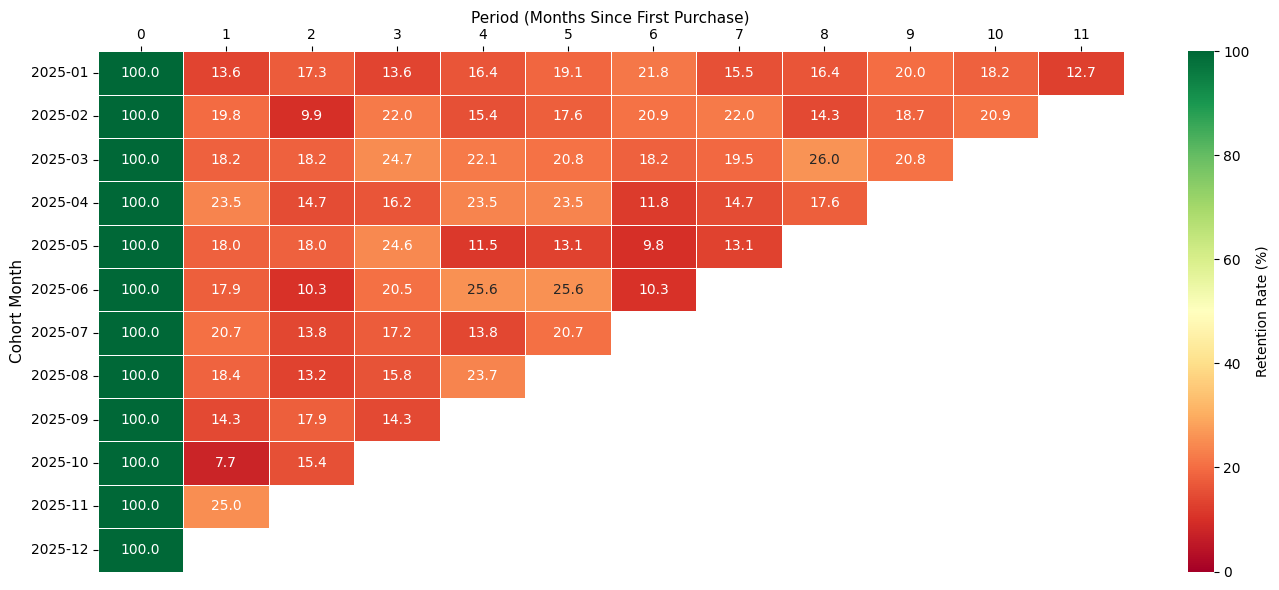

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cohort_pivot_percent,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'}
)

# ax.set_title('Monthly Cohort Retention Heatmap', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

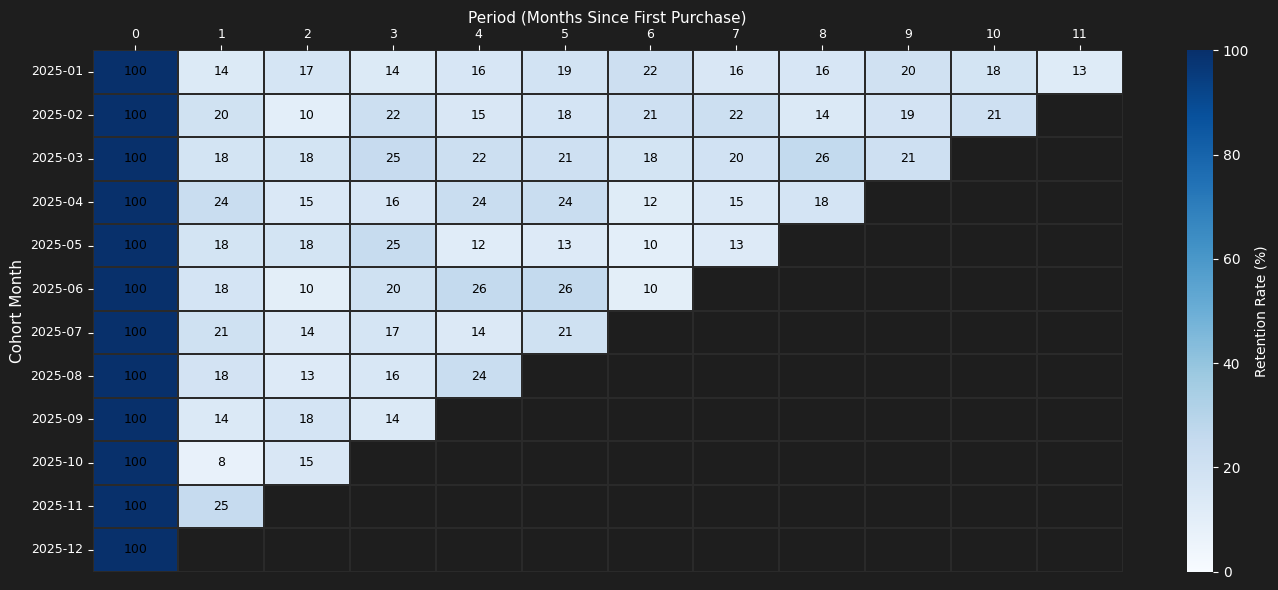

In [ ]:
# Set dark background
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 6))

# Custom blue colormap
cmap = sns.color_palette("Blues", as_cmap=True)

sns.heatmap(
    cohort_pivot_percent,
    annot=True,
    fmt='.0f',
    cmap=cmap,
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#2a2a2a',  # grid subtle
    ax=ax,
    cbar_kws={'label': 'Retention Rate (%)'},
    annot_kws={"color": "black", "fontsize": 9}
)

# Background color
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#1e1e1e')

# Labels
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11, color='white')
ax.set_ylabel('Cohort Month', fontsize=11, color='white')

# Move x-axis to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Tick styling
ax.tick_params(colors='white', labelsize=9)

# Remove spines (clean BI look)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('cohort_heatmap_dark.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

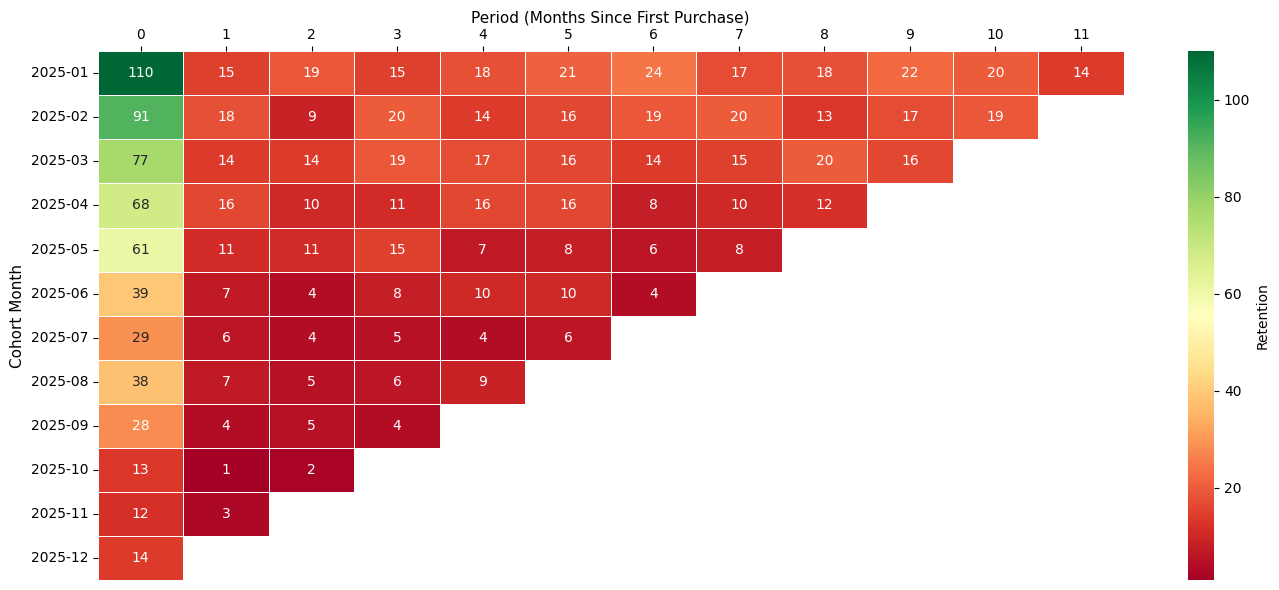

In [59]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    cohort_pivot_absolute,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention'}
)

# ax.set_title('Monthly Cohort Retention Heatmap', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11)
ax.set_ylabel('Cohort Month', fontsize=11)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

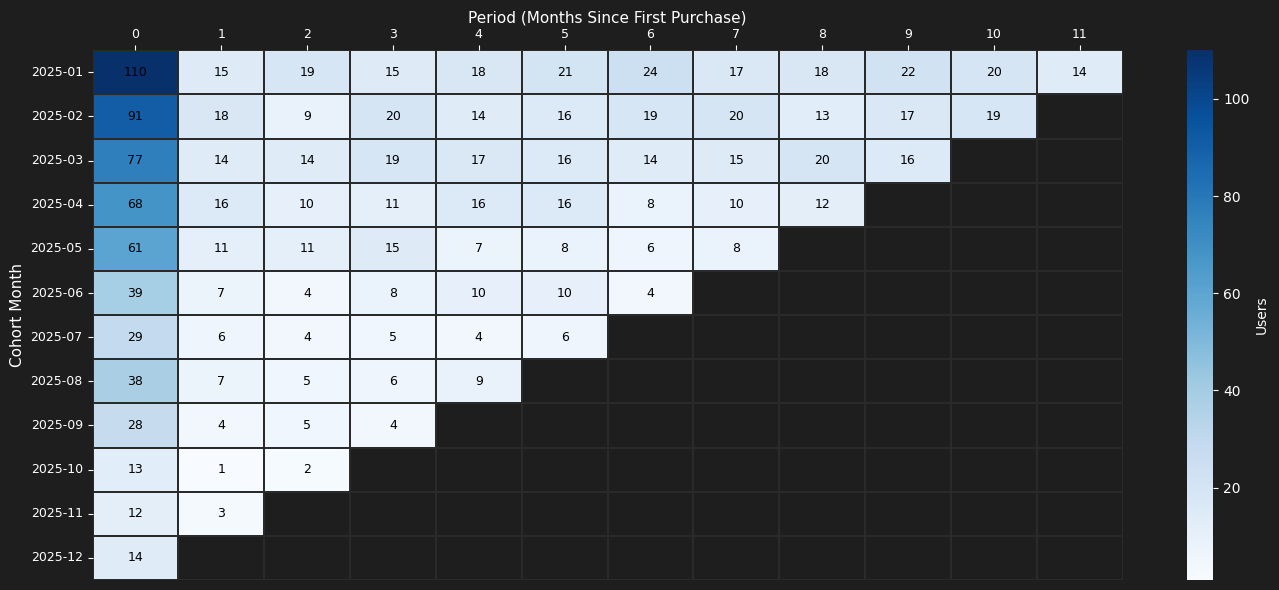

In [74]:
# Dark theme
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 6))

# Blue gradient giống BI
cmap = sns.color_palette("Blues", as_cmap=True)

sns.heatmap(
    cohort_pivot_absolute,
    annot=True,
    fmt='.0f',  # số nguyên (không phải %)
    cmap=cmap,
    linewidths=0.3,
    linecolor='#2a2a2a',
    ax=ax,
    cbar_kws={'label': 'Users'},
    annot_kws={"color": "black", "fontsize": 9}
)

# Background
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#1e1e1e')

# Labels
ax.set_xlabel('Period (Months Since First Purchase)', fontsize=11, color='white')
ax.set_ylabel('Cohort Month', fontsize=11, color='white')

# Move x-axis lên trên
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Style ticks
ax.tick_params(colors='white', labelsize=9)

# Remove border (BI clean look)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('cohort_heatmap_absolute_dark.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

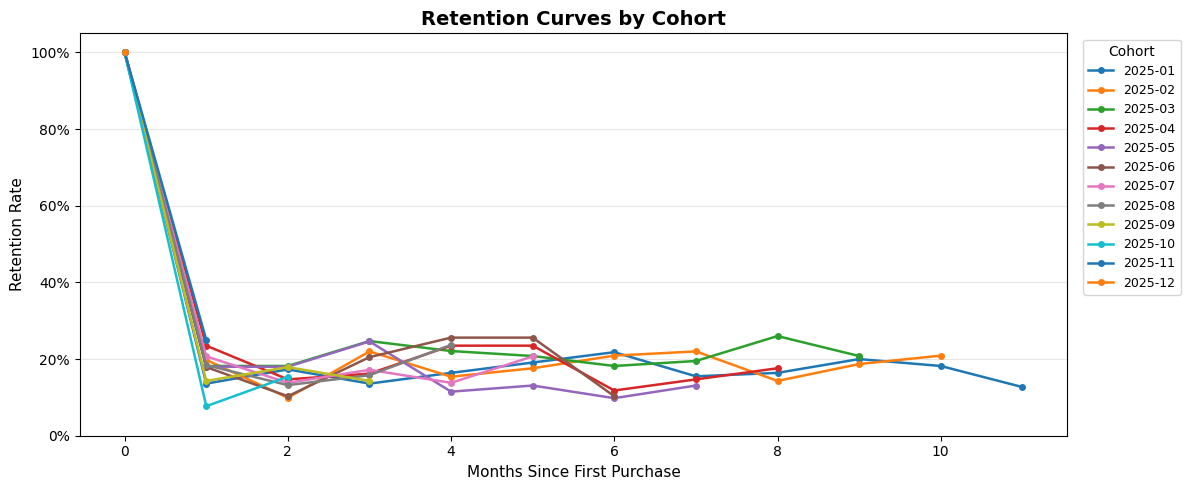

In [60]:
fig, ax = plt.subplots(figsize=(12, 5))

for cohort in cohort_pivot_percent.index:
    ax.plot(
        cohort_pivot_percent.columns,
        cohort_pivot_percent.loc[cohort],
        marker='o', markersize=4,
        label=cohort, linewidth=1.8
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Retention Rate', fontsize=11)
ax.set_title('Retention Curves by Cohort', fontsize=14, fontweight='bold')
ax.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cohort_curves.png', dpi=150, bbox_inches='tight')
plt.show()

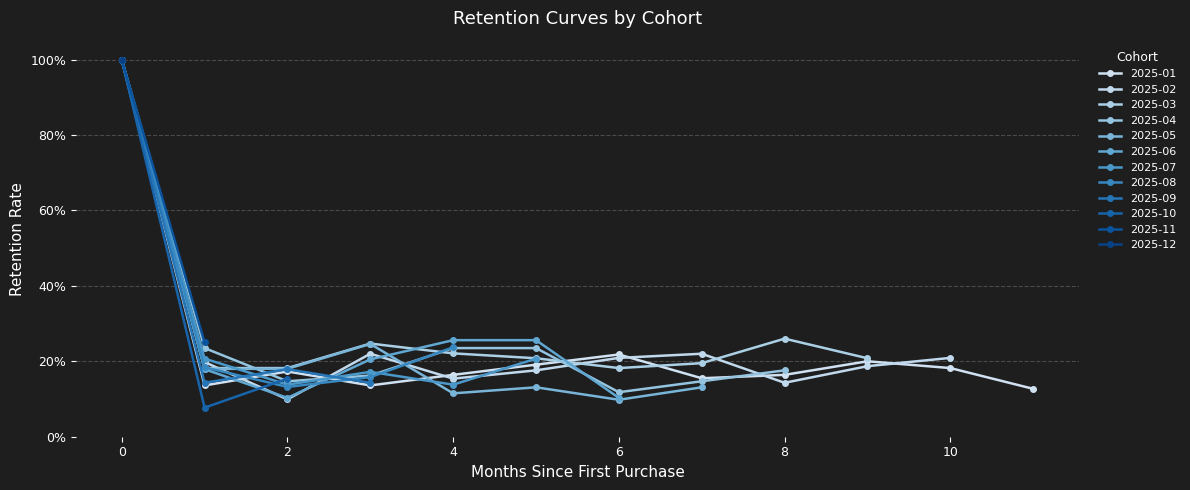

In [75]:
# Dark theme
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(12, 5))

# Color palette (blue gradient cho nhiều cohort)
colors = sns.color_palette("Blues", n_colors=len(cohort_pivot_percent.index) + 2)[2:]

for i, cohort in enumerate(cohort_pivot_percent.index):
    ax.plot(
        cohort_pivot_percent.columns,
        cohort_pivot_percent.loc[cohort],
        marker='o',
        markersize=4,
        linewidth=1.8,
        color=colors[i],
        label=cohort
    )

# Background
ax.set_facecolor('#1e1e1e')
fig.patch.set_facecolor('#1e1e1e')

# Axis labels
ax.set_xlabel('Months Since First Purchase', fontsize=11, color='white')
ax.set_ylabel('Retention Rate', fontsize=11, color='white')

# Percent format
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Title (optional BI style: nhẹ hơn, không quá bold)
ax.set_title('Retention Curves by Cohort', fontsize=13, color='white', pad=12)

# Legend (clean BI style)
ax.legend(
    title='Cohort',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

# Grid nhẹ
ax.grid(axis='y', linestyle='--', alpha=0.2)

# Tick styling
ax.tick_params(colors='white', labelsize=9)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Limit
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('cohort_curves_dark.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()